# 16 &middot; Mass-Spring Actuation: Pulling Surface Tendons to Steer a Beam

The previous tutorial built a soft actuator out of a sealed **pneumatic chamber**
&mdash; pump area in, the wall pushes outward, the beam bends. This notebook tells
the *same* story with a different actuator: **contractile springs** glued to the
surface of the beam, like tendons or artificial muscles.

A single spring (tutorial&nbsp;11) stores
$\tfrac12 k\,(\lVert x_j-x_i\rVert - l_0)^2$ and pulls its endpoints toward its
rest length $l_0$. A real tendon *actuates* by **shortening its own rest length**:
drop $l_0$ and the spring contracts, dragging whatever it is attached to. We bolt
two such springs onto a neo-Hookean beam &mdash; one along the **top** surface,
one along the **bottom** &mdash; and command their rest lengths.

$$
E_{\text{spring}}(x) \;=\; \tfrac12\,k\,\bigl(l(x) - l_0^\star\bigr)^2 ,
\qquad k=\frac{\text{ym}}{l_0^2},
$$

with $l(x)=\lVert x_j-x_i\rVert$ the current length and $l_0^\star$ the
**commanded** rest length. Its gradient $k\,(l-l_0^\star)\,\nabla l$ is a force of
magnitude $k(l-l_0^\star)$ pulling the two endpoints together along the edge
&mdash; Hooke's law. Coupling it to a **nonlinear neo-Hookean** elastic beam
(full-order FEM, no subspace) and pinning the left wall, we solve the
**quasistatic** equilibrium

$$
x^\star \;=\; \arg\min_x \;\;
\underbrace{E_{\text{neo}}(x)}_{\text{beam elasticity}}
\;+\; \underbrace{\sum_{s\in\{\text{top},\text{bot}\}}\tfrac12 k_s\bigl(l_s(x)-l_{0,s}^\star\bigr)^2}_{\text{two surface tendons}}
\;+\; \underbrace{\tfrac12\lVert x_{\text{pin}}-X_{\text{pin}}\rVert^2_K}_{\text{clamp the left wall}}
$$

at every step of a slowly shortening rest length. Contract the **top** tendon and
the top fibers are dragged together &mdash; the cantilever curls **up**; contract
the **bottom** and it curls **down**. Drive the two **differently** and you dial
in any deflection angle in between.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

os.makedirs("media", exist_ok=True)

TOP_C     = "#c0392b"   # top tendon
BOT_C     = "#08519c"   # bottom tendon
WALL_FACE = "#cfe8df"   # beam fill
WALL_EDGE = "#2a7f62"   # beam mesh edges
PIN_C     = "#3182bd"   # pinned-wall markers
NODE_C    = "#e6550d"   # tendon endpoints

## A beam with two surface tendons

We mesh the beam as a structured triangle grid so its corners and mid-span
vertices are easy to name. Two actuator springs are attached to the surface:

* the **top tendon** runs from the **top-left** vertex to the **top-middle**
  vertex,
* the **bottom tendon** runs from the **bottom-left** vertex to the
  **bottom-middle** vertex.

Each spans the left half of the beam, just inboard of the clamped wall &mdash;
exactly where a tendon has the most leverage to bend a cantilever. Their natural
rest length is simply the distance they cover at rest; *actuating* a tendon means
commanding a **shorter** rest length so it tries to reel its two endpoints in.

mesh: 203 vertices, 336 triangles
tendon rest lengths: top 1.750,  bottom 1.750


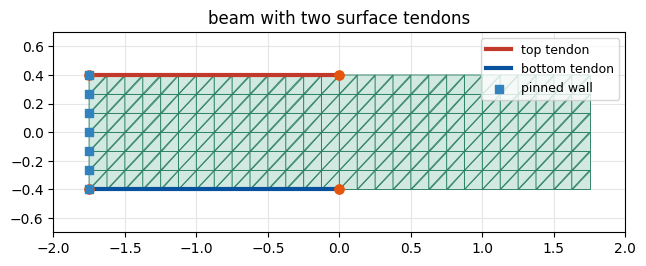

In [2]:
def beam_with_tendons(L=3.5, H=0.8, nx=29, ny=7):
    '''Structured triangle-grid beam (L x H). Returns the mesh and the two
    actuator edges E_act = [[top-left, top-mid], [bottom-left, bottom-mid]]
    (row 0 = top tendon, row 1 = bottom tendon).'''
    X, T = utils.triangulated_grid(nx, ny, width=L, height=H)
    mid = nx // 2
    top_left,  top_mid = (ny - 1) * nx + 0, (ny - 1) * nx + mid
    bot_left,  bot_mid = 0,                 mid
    E_act = np.array([[top_left, top_mid], [bot_left, bot_mid]])
    return X, T, E_act


# Build one beam and look at it.
X, T, E_act = beam_with_tendons()
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
l0_rest = simkit.edge_lengths(X, E_act).reshape(-1, 1)
print(f"mesh: {X.shape[0]} vertices, {T.shape[0]} triangles")
print(f"tendon rest lengths: top {l0_rest[0,0]:.3f},  bottom {l0_rest[1,0]:.3f}")

fig, ax = plt.subplots(figsize=(8, 2.6))
utils.PolyMeshArtist(ax, X, T, facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.7)
for (i, j), c, lbl in zip(E_act, [TOP_C, BOT_C], ["top tendon", "bottom tendon"]):
    ax.plot(X[[i, j], 0], X[[i, j], 1], "-", color=c, lw=3.0, zorder=4, label=lbl)
    ax.scatter(X[[i, j], 0], X[[i, j], 1], s=45, color=NODE_C, zorder=5)
ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=40, marker="s", color=PIN_C, zorder=5,
           label="pinned wall")
utils.setup_axes(ax, (-2.0, 2.0), (-0.7, 0.7), title="beam with two surface tendons")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## The actuation energy

`TendonBeam` assembles the three terms of the objective:

* **Neo-Hookean elasticity** &mdash; the full-order, *nonlinear* FEM energy from
  tutorial&nbsp;3/4 (`macklin_mueller_neo_hookean_*_x`). Every mesh vertex is a
  degree of freedom; no reduction.
* **Two tendons** &mdash; $\sum_s \tfrac12 k_s (l_s(x)-l_{0,s}^\star)^2$. We reuse
  `simkit.energies.mass_springs_*_z` from tutorial&nbsp;11: the edge-difference
  operator $J$ maps the global positions straight to the two edge vectors, so the
  spring force, Hooke stiffness, and rest-length are exactly the single-spring
  ones &mdash; just scattered onto the right surface DOFs.
* **Pin** &mdash; a stiff `dirichlet_penalty` clamping the left wall in place.

The commanded rest lengths $l_{0,s}^\star$ are the **control inputs**. For the
Hessian we keep the PSD-projected elastic block plus the PSD-projected spring
block (`psd=True`): a contracting spring ($l>l_0^\star$) is in tension and convex,
but the moment one goes slack the raw spring Hessian turns indefinite, so the
projection keeps Newton positive-definite and robust.

In [3]:
class TendonBeam:
    '''Quasistatic neo-Hookean beam with two contractile surface tendons and a
    pinned wall. Actuate by commanding each tendon\'s rest length.'''

    def __init__(self, X, T, E_act, E_young=1e4, nu=0.45,
                 ym_spring=2e3, K_pin=1e9):
        self.X, self.T   = X, T
        self.n, self.dim = X.shape
        self.J   = simkit.deformation_jacobian(X, T)
        self.vol = simkit.volume(X, T)
        mu, lam  = utils.lame_from_E_nu(E_young, nu)
        self.mu  = np.full((len(T), 1), mu)
        self.lam = np.full((len(T), 1), lam)

        # --- two surface tendons ---
        self.E_act = E_act
        Be   = simkit.edge_displacement_jacobian(X, E_act)        # edges <- vertices
        self.Js = sps.kron(Be, sps.eye(self.dim)).tocsc()         # d = Js x stacks edge vectors
        self.l0_rest = simkit.edge_lengths(X, E_act).reshape(-1, 1)
        self.l0      = self.l0_rest.copy()                        # commanded rest length
        self.ym      = np.full((E_act.shape[0], 1), ym_spring)
        self.vols    = np.ones((E_act.shape[0], 1))

        # --- pin the left wall ---
        self.pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
        self.Qp, self.bp = simkit.dirichlet_penalty(self.pin_idx, X[self.pin_idx],
                                                    self.n, K_pin)

    def tension(self, x):
        '''Per-tendon tension f = k (l - l0*) (positive = pulling in).'''
        l = simkit.edge_lengths(x.reshape(-1, self.dim), self.E_act).reshape(-1, 1)
        k = self.ym / self.l0_rest ** 2
        return (k * (l - self.l0)).ravel()

    def energy(self, x):
        xn = x.reshape(-1, self.dim)
        E_el  = energies.macklin_mueller_neo_hookean_energy_x(xn, self.J, self.mu, self.lam, self.vol)
        E_sp  = energies.mass_springs_energy_z(x, self.Js, self.ym, self.vols, self.l0)
        E_pin = 0.5 * (x.T @ (self.Qp @ x))[0, 0] + (self.bp.T @ x)[0, 0]
        return E_el + E_sp + E_pin

    def gradient(self, x):
        xn = x.reshape(-1, self.dim)
        g  = energies.macklin_mueller_neo_hookean_gradient_x(xn, self.J, self.mu, self.lam, self.vol).copy()
        g += energies.mass_springs_gradient_z(x, self.Js, self.ym, self.vols, self.l0)   # tendon pull
        g += self.Qp @ x + self.bp
        return g

    def hessian(self, x):
        xn = x.reshape(-1, self.dim)
        He = energies.macklin_mueller_neo_hookean_hessian_x(xn, self.J, self.mu, self.lam, self.vol, psd=True)
        Hs = energies.mass_springs_hessian_z(x, self.Js, self.ym, self.vols, self.l0, psd=True)
        return (He + Hs + self.Qp).tocsc()

    def contract_to(self, l0, U0, iters=40):
        '''Quasistatic Newton solve at fixed commanded rest lengths.'''
        self.l0 = np.asarray(l0).reshape(-1, 1)
        x = newton_solver(U0.reshape(-1, 1), self.energy, self.gradient, self.hessian, max_iter=iters, do_line_search=True)
        return x.reshape(self.n, self.dim)

## Quasistatically contracting the tendons

There is no time, mass, or velocity here &mdash; this is **quasistatic**. We ramp
each tendon's commanded rest length from its natural value down toward a target
fraction, and at each step re-solve for static equilibrium with Newton,
warm-starting from the previous pose. Each frame is the beam holding still at the
current actuation, so the animation reads as a muscle *slowly* contracting.

top tendon length 1.750 -> 0.934
tip deflection angle: +35.5 deg
peak top-tendon tension f = 213.0


saved media/16_tendon_contract.mp4



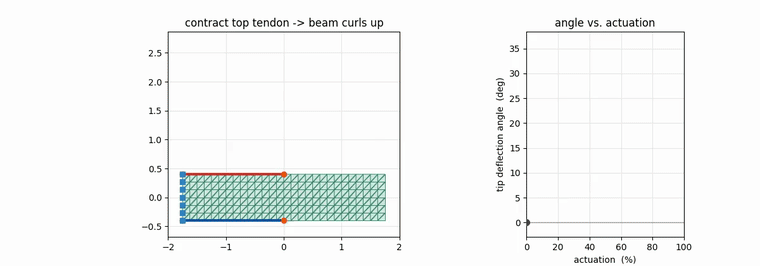

In [4]:
def actuate(beam, top_ratio=1.0, bot_ratio=1.0, n_steps=28):
    '''Ramp the top/bottom commanded rest lengths to (ratio x natural), solving
    each step. Returns the poses, per-tendon lengths, and tensions.'''
    U = beam.X.copy()
    states, lengths, tens = [U.copy()], [beam.l0_rest.ravel().copy()], [np.zeros(2)]
    for s in np.linspace(0, 1, n_steps)[1:]:
        f = np.array([[1 + s * (top_ratio - 1)], [1 + s * (bot_ratio - 1)]])
        U = beam.contract_to(beam.l0_rest * f, U)
        states.append(U.copy())
        lengths.append(simkit.edge_lengths(U, beam.E_act))
        tens.append(beam.tension(U.reshape(-1, 1)))
    return np.array(states), np.array(lengths), np.array(tens)


def tip_angle(beam, U):
    '''Deflection angle (deg) of the cantilever tip relative to rest.'''
    tip = np.where(beam.X[:, 0] >= beam.X[:, 0].max() - 1e-6)[0]
    dy  = U[tip, 1].mean() - beam.X[tip, 1].mean()
    span = beam.X[:, 0].max() - beam.X[:, 0].min()
    return np.degrees(np.arctan2(dy, span))


def animate_actuation(beam, states, angles, *, title="", fps=18):
    '''Left: the beam bending as its tendons contract (tendons drawn on top).
    Right: tip deflection angle vs actuation. Returns (fig, anim).'''
    xs = np.linspace(0, 100, len(states))                       # actuation %
    xlim, ylim = utils.auto_limits(states, pad=0.25)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2),
                                   gridspec_kw={"width_ratios": [2.4, 1]})
    utils.setup_axes(axL, xlim, ylim, title=title)
    mesh = utils.PolyMeshArtist(axL, states[0], beam.T, facecolor=WALL_FACE,
                                edgecolor=WALL_EDGE, lw=0.7)
    tendons = []
    for (i, j), c in zip(beam.E_act, [TOP_C, BOT_C]):
        (ln,) = axL.plot([], [], "-", color=c, lw=3.0, zorder=4)
        tendons.append((ln, i, j))
    (nodes,) = axL.plot([], [], "o", color=NODE_C, ms=6, zorder=5)
    axL.scatter(beam.X[beam.pin_idx, 0], beam.X[beam.pin_idx, 1], s=35, marker="s",
                color=PIN_C, zorder=5)

    trace = utils.TracePlot(axR, xs, {"tip angle": angles}, colors={"tip angle": "#444"},
                            xlabel="actuation  (%)", ylabel="tip deflection angle  (deg)",
                            title="angle vs. actuation")
    axR.axhline(0, color="0.6", lw=1.0)

    def update(i):
        U = states[i]
        mesh.update(U)
        ends = []
        for ln, a, b in tendons:
            ln.set_data(U[[a, b], 0], U[[a, b], 1])
            ends += [a, b]
        nodes.set_data(U[ends, 0], U[ends, 1])
        trace.update(i)
        return ()

    anim = FuncAnimation(fig, update, frames=len(states), interval=1000 / fps, blit=False)
    return fig, anim


# Contract the TOP tendon to 40% of its rest length -> cantilever curls up.
X, T, E_act = beam_with_tendons()
beam = TendonBeam(X, T, E_act)
states, lengths, tens = actuate(beam, top_ratio=0.4, bot_ratio=1.0)
angles = np.array([tip_angle(beam, U) for U in states])
print(f"top tendon length {lengths[0,0]:.3f} -> {lengths[-1,0]:.3f}")
print(f"tip deflection angle: {angles[-1]:+.1f} deg")
print(f"peak top-tendon tension f = {tens[:,0].max():.1f}")

fig, anim = animate_actuation(beam, states, angles, title="contract top tendon -> beam curls up")
out = utils.save_anim(anim, "media/16_tendon_contract.mp4", fps=18)
print("saved", out)
html = utils.show_anim(anim, fps=14, width=760)
plt.close(fig)
html

## Steering: which tendon you pull sets the bend

The two tendons are the actuator's *control inputs*. Contract the **top** one and
the top fibers are reeled in &mdash; the beam curls **up**. Contract the
**bottom** one and it curls **down**. Contract **both equally** and the pulls are
symmetric: the beam shortens but barely bends. We run the same quasistatic
contraction for three actuation patterns and play them side by side.

contract top  ->  curls up          tip angle = +35.5 deg


contract both  ->  no net bend      tip angle = -3.4 deg


contract bottom  ->  curls down     tip angle = -34.9 deg


saved media/16_tendon_steering.mp4



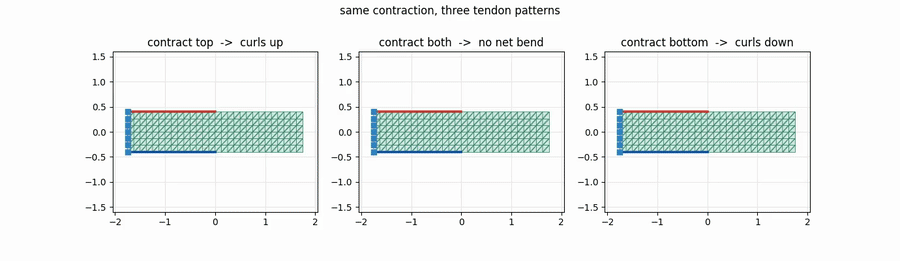

In [5]:
designs = [
    ("contract top  ->  curls up",     0.4, 1.0),
    ("contract both  ->  no net bend", 0.4, 0.4),
    ("contract bottom  ->  curls down", 1.0, 0.4),
]

panels = []
for label, tr, br in designs:
    bd = TendonBeam(X, T, E_act)
    sd, _, _ = actuate(bd, top_ratio=tr, bot_ratio=br)
    panels.append({"states": sd, "T": T, "title": label, "E_act": E_act,
                   "ratios": (tr, br)})
    print(f"{label:34s}  tip angle = {tip_angle(bd, sd[-1]):+.1f} deg")


def animate_beams_grid(panels, *, lims, fps=18, suptitle=None):
    '''Several tendon-beams side by side, tendons overlaid, played in sync.'''
    npan = len(panels)
    fig, axes = plt.subplots(1, npan, figsize=(4.6 * npan, 4.0), squeeze=False)
    axes = axes[0]
    nframes = max(len(p["states"]) for p in panels)
    arts = []
    for ax, p in zip(axes, panels):
        utils.setup_axes(ax, lims[0], lims[1], title=p["title"])
        mesh = utils.PolyMeshArtist(ax, p["states"][0], p["T"], facecolor=WALL_FACE,
                                    edgecolor=WALL_EDGE, lw=0.6)
        lns = []
        for (i, j), c in zip(p["E_act"], [TOP_C, BOT_C]):
            (ln,) = ax.plot([], [], "-", color=c, lw=2.6, zorder=4)
            lns.append((ln, i, j))
        ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=30, marker="s", color=PIN_C, zorder=5)
        arts.append((mesh, lns))

    def update(k):
        for (mesh, lns), p in zip(arts, panels):
            U = p["states"][min(k, len(p["states"]) - 1)]
            mesh.update(U)
            for ln, a, b in lns:
                ln.set_data(U[[a, b], 0], U[[a, b], 1])
        return ()

    anim = FuncAnimation(fig, update, frames=nframes, interval=1000 / fps, blit=False)
    if suptitle:
        fig.suptitle(suptitle)
    return fig, anim


fig, anim = animate_beams_grid(panels, lims=((-2.05, 2.05), (-1.6, 1.6)),
                               fps=18, suptitle="same contraction, three tendon patterns")
out = utils.save_anim(anim, "media/16_tendon_steering.mp4", fps=18)
print("saved", out)
html = utils.show_anim(anim, fps=14, width=900)
plt.close(fig)
html

## A deflection gallery

Holding the *total* contraction fixed and sliding it from the bottom tendon to
the top one sweeps out a fan of deflection angles &mdash; continuous steering
authority from a single differential knob. We parametrize it by an asymmetry
$d\in[-0.4,\,0.4]$: the top tendon is commanded to $(1+d)\times$ its rest length
and the bottom to $(1-d)\times$. $d<0$ shortens the top (curls up), $d>0$
shortens the bottom (curls down), $d=0$ is the rest beam. Each fully-actuated
pose is overlaid on its rest shape (grey) and labeled with the tip angle.

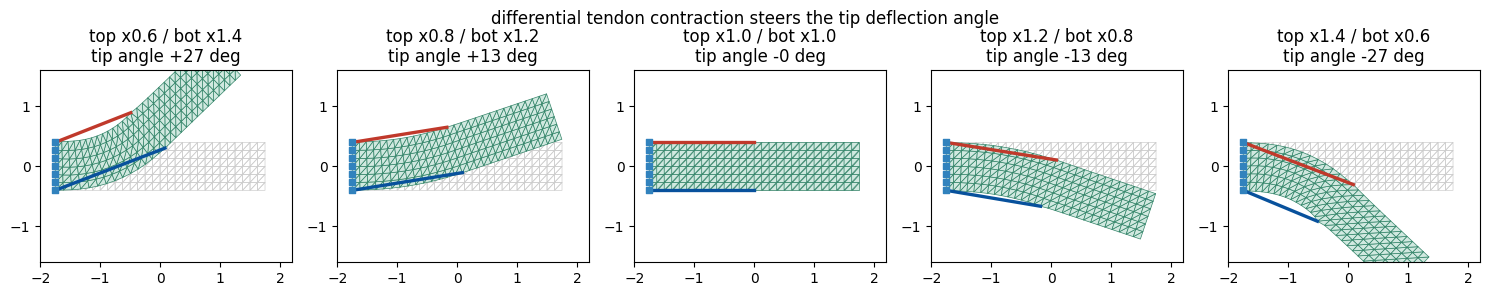

In [6]:
asyms = [-0.4, -0.2, 0.0, 0.2, 0.4]
fig, axes = plt.subplots(1, len(asyms), figsize=(3.0 * len(asyms), 2.8), squeeze=False)
for ax, d in zip(axes[0], asyms):
    bg = TendonBeam(X, T, E_act)
    sg, _, _ = actuate(bg, top_ratio=1 + d, bot_ratio=1 - d)
    U   = sg[-1]
    ang = tip_angle(bg, U)
    utils.PolyMeshArtist(ax, X, T, facecolor="none", edgecolor="0.8", lw=0.5)     # rest ghost
    utils.PolyMeshArtist(ax, U, T, facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.5)
    for (i, j), c in zip(E_act, [TOP_C, BOT_C]):
        ax.plot(U[[i, j], 0], U[[i, j], 1], "-", color=c, lw=2.4, zorder=4)
    ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=16, marker="s", color=PIN_C, zorder=5)
    utils.setup_axes(ax, (-2.0, 2.2), (-1.6, 1.6),
                     title=f"top x{1+d:.1f} / bot x{1-d:.1f}\ntip angle {ang:+.0f} deg",
                     grid=False)
fig.suptitle("differential tendon contraction steers the tip deflection angle")
fig.tight_layout()
fig.savefig("media/16_tendon_gallery.png", dpi=130, bbox_inches="tight")
plt.show()

### Takeaways

* A contractile tendon is just a **spring whose rest length you command**:
  penalizing $\tfrac12 k (l(x)-l_0^\star)^2$ and lowering $l_0^\star$ pulls its two
  endpoints together, and its gradient $k(l-l_0^\star)\nabla l$ is a genuine
  Hooke force along the edge (tutorial&nbsp;11).
* Glued to the surface of a **nonlinear neo-Hookean** full-order beam and a
  pinned wall, ramping the rest lengths and re-solving with Newton gives a clean
  **quasistatic** actuation &mdash; the same recipe as the pneumatic chamber, with
  an off-center *spring* in place of an off-center *chamber*.
* The raw spring Hessian goes indefinite when a tendon slackens; the
  **PSD-projected** block keeps the solve positive-definite and robust.
* **Where and how hard you pull is steering**: a top tendon curls the cantilever
  up, a bottom one curls it down, and the *differential* contraction sets the
  deflection angle. Real soft robots and tendon-driven fingers chain many such
  actuators to reach, grip, and crawl.